In [7]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.animation as animation

import sys
sys.path.append('../')
from src.config import GROUP_PARAMS, calculate_velocity_grid, VELOCITY_SPACE, COLLISION_PARAMS

In [12]:
Ak_data = np.load('../simulation_data/Ak_t0_20250514_011627.npy')
bk_data = np.load('../simulation_data/bk_t0_20250514_011627.npy')
wxk_data = np.load('../simulation_data/wxk_t0_20250514_011627.npy')
wyk_data = np.load('../simulation_data/wyk_t0_20250514_011627.npy')
wzk_data = np.load('../simulation_data/wzk_t0_20250514_011627.npy')
meta_data = np.load('../simulation_data/metadata_t0_20250514_011627.npy', allow_pickle=True)

print(wxk_data)

[[[[ 0.63179431  0.63179431]
   [ 0.63179431  0.63179431]]

  [[-0.63179431 -0.63179431]
   [-0.63179431 -0.63179431]]]]


In [13]:
cx_vec, cy_vec, cz_vec, cx, cy, cz = calculate_velocity_grid()

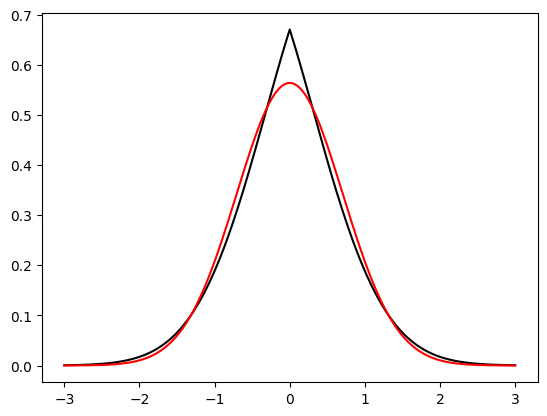

In [23]:
fig = plt.figure()
ax1 = fig.add_subplot(111)

combined_f = np.zeros((VELOCITY_SPACE['num_cx'], VELOCITY_SPACE['num_cy'], VELOCITY_SPACE['num_cz']))

for i in range(0, GROUP_PARAMS['num_groups_cx']):
    for j in range(0, GROUP_PARAMS['num_groups_cy']):
        for k in range(0, GROUP_PARAMS['num_groups_cz']):
            f = Ak_data[0, i, j, k] * np.exp(-bk_data[0, i, j, k] * ((cx - wxk_data[0, i, j, k])**2 + (cy - wyk_data[0, i, j, k])**2 + (cz - wzk_data[0, i, j, k])**2))

            lb_cx = GROUP_PARAMS['group_bounds_cx'][i, 0]
            ub_cx = GROUP_PARAMS['group_bounds_cx'][i, 1]
            lb_cy = GROUP_PARAMS['group_bounds_cy'][j, 0]
            ub_cy = GROUP_PARAMS['group_bounds_cy'][j, 1]
            lb_cz = GROUP_PARAMS['group_bounds_cz'][k, 0]
            ub_cz = GROUP_PARAMS['group_bounds_cz'][k, 1]

            combined_f[lb_cx:ub_cx, lb_cy:ub_cy, lb_cz:ub_cz] = f[lb_cx:ub_cx, lb_cy:ub_cy, lb_cz:ub_cz]

combined_f_Ix = np.trapz(np.trapz(combined_f, cy_vec, axis=1), cx_vec, axis=0)
f0 = 1 / (np.pi**1.5) * np.exp(-1 * (cx**2 + cy**2 + cz**2))
f0I = np.trapz(np.trapz(f0, cz_vec, axis=2), cy_vec, axis=1)

ax1.plot(cx_vec, combined_f_Ix, color='black')
ax1.plot(cx_vec, f0I, color='red')

plt.show()